Preprocesses the nuclear fuel demographic/economic dataset, trains a regularized logistic regression model,
evaluates performance with cross-validation, and displays the variables via a correlation coefficent & bar graph.
<br>Date: 11/8/25
<br>Author: Melody Qian

In [61]:
#Imported more than necessary lol
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
import os

In [51]:
#Read and clean the data
df=pd.read_csv("/Users/melodyqian/Documents/GitHub/FindMyNuclearWaste/data/MLDataset.csv")
dummydf = pd.get_dummies(df, columns=['Urban_Rural'], drop_first=True)
dummydf= dummydf[dummydf['house_value_median']>0]
dummydf=dummydf[dummydf['county_data']==0]
collinear= ['household_income_median','nonhispanic_percent', 'white_percent','femalepercent','missing_race','county_data', 'index']
dummydf = dummydf.drop(columns=collinear, axis=1)

cont_cols = ['occupied_percent' ,'house_value_median', 'age_median', 'malepercent', 'hispanic_percent', 'black_percent', 'asian_percent', 'pacific_percent','native_percent', 'median_family_percent']  # numeric feature names
bin_cols = ['Urban_Rural_Rural', 'Urban_Rural_Urban']  # categorical feature names



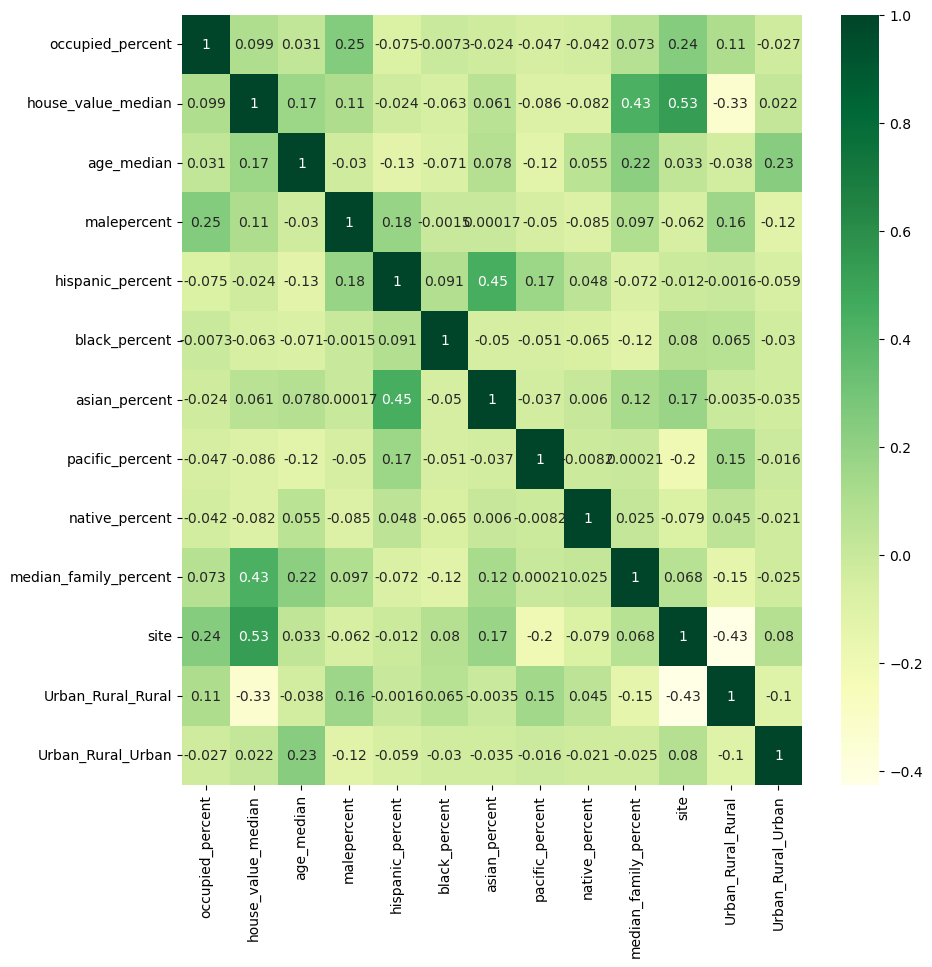

In [ ]:
plt.figure(figsize = (10, 10))
sns.heatmap(dummydf.corr(), cmap='YlGn',annot = True)
os.chdir('/Users/melodyqian/Documents/GitHub/FindMyNuclearWaste/Visuals')
plt.savefig('heatmap.png')


In [28]:
#Preprocessing
pre = ColumnTransformer([
    ("num", StandardScaler(), cont_cols),   # scale continuous only
    ("bin", "passthrough", bin_cols),       # leave 0/1 as-is
])

In [69]:
y = dummydf['site']                     # categorical
X = dummydf.drop(columns=['site'])

clf = LogisticRegression(
    penalty="l1", solver="liblinear", max_iter=2000, C=1.0, random_state=30
)

model = Pipeline([("pre", pre), ("clf", clf)])

In [70]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring="accuracy") #Scores of 5 models

model.fit(X_tr, y_tr) #Train final model on all data
y_tr_pred = model.predict(X_tr) #train predict
y_te_pred = model.predict(X_te) #Test predict


In [71]:
print(f"CV accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print("Train acc:", accuracy_score(y_tr, y_tr_pred))
print("Test  acc:", accuracy_score(y_te, y_te_pred))

CV accuracy: 0.910 ± 0.057
Train acc: 0.9772727272727273
Test  acc: 0.9090909090909091


In [72]:
logit = model.named_steps["clf"]
feature_names = model.named_steps["pre"].get_feature_names_out()

coefs = logit.coef_.ravel()  # shape (12,)
intercept = logit.intercept_[0]

# Pair names with weights
for name, w in sorted(zip(feature_names, coefs), key=lambda x: abs(x[1]), reverse=True):
    print(f"{name:40s} {w:+.4f}")
print("Intercept:", intercept)

num__house_value_median                  +6.5889
num__asian_percent                       +1.1976
num__median_family_percent               -0.4243
num__hispanic_percent                    -0.3947
num__occupied_percent                    +0.3758
num__pacific_percent                     -0.2957
num__black_percent                       +0.2790
bin__Urban_Rural_Rural                   -0.1267
num__malepercent                         -0.0193
num__age_median                          +0.0000
num__native_percent                      +0.0000
bin__Urban_Rural_Urban                   +0.0000
Intercept: 2.1862062931400215


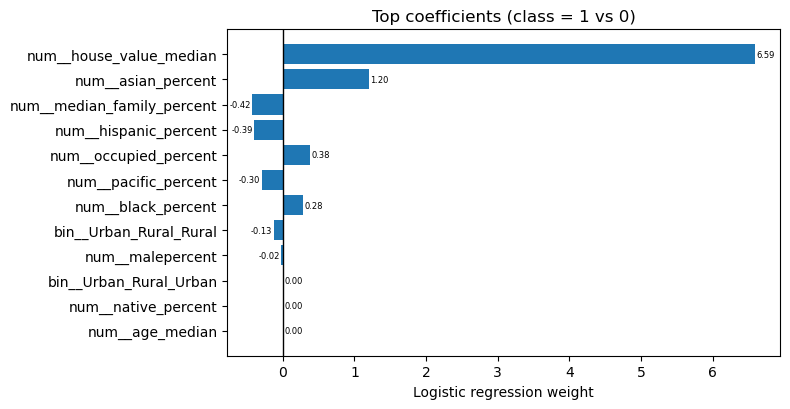

In [73]:
order = np.argsort(np.abs(coefs))[::-1]
names_sorted = feature_names[order]
coefs_sorted = coefs[order]

N = min(25, len(coefs_sorted))
fig, ax = plt.subplots(figsize=(8, max(4, N*0.35)))

bars = ax.barh(range(N), coefs_sorted[:N])
ax.set_yticks(range(N))
ax.set_yticklabels(names_sorted[:N])
ax.invert_yaxis()  # largest at top
ax.set_xlabel("Logistic regression weight")
ax.set_title("Top coefficients (class = 1 vs 0)")

# draw a zero line for reference
ax.axvline(0, color="k", linewidth=1)

# add labels: show sign and 4 decimals; pad a few pixels from the bar end
ax.bar_label(bars, fmt="%.2f", padding=1, fontsize=6)

plt.tight_layout()
plt.show()